# Windowed moment estimators

Every moment estimator in the previous pages used the **whole** return sample with equal weight
on each observation. That is the right default when the data-generating process is stable, but
markets are not: volatility clusters, correlations spike in crises, and a name's risk today looks
nothing like its risk three years ago. **Windowed estimators** restrict — or reweight — the
observations a moment is computed from, so the estimate reflects a chosen slice of history rather
than the full sample.

`PortfolioOptimisers` wraps each moment estimator in a windowed variant —
`WindowedExpectedReturns`, `WindowedCovariance`, `WindowedVariance`,
`WindowedCoskewness`, `WindowedCokurtosis` — each carrying two controls:

  - `window` — either an integer (use the **last `window` observations**, a trailing recency
    window) or a vector of indices (use a **specific, hand-picked sub-period**).
  - `w` — optional observation weights ([`eweights`](https://juliastats.org/StatsBase.jl/stable/weights/)
    and friends), to taper the influence of older observations *without* a hard cutoff.

Each call still returns **one** moment — a single mean vector or covariance matrix for the
selected window. The estimator does not itself produce a rolling time series; sliding a window
through time is something the caller drives, as the last section shows.

> **When to reach for this**
>
> Reach for a windowed estimator when recency matters: when you believe the recent regime is
> more informative than the distant past (use a short trailing `window` or `eweights`), or when
> you want to condition a moment on a *specific* historical episode — a crisis, a calm stretch,
> a single earnings cycle (use an index-vector `window`). If you trust the full sample as
> representative, the plain estimators from the earlier pages are the right default.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, Statistics, StatsBase, StatsPlots,
      PrettyTables, LinearAlgebra, Clarabel

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 2)) %" : v
    end
end;

## 1. Data

Windowing only earns its keep when there is enough history for the windows to differ, so unlike
the other examples we take a longer slice — roughly four years of daily S&P 500 returns rather
than one. The aligned timestamps (`rd.ts`) let us point windows at named calendar episodes later.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 1008):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 1008×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 1008-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Window length as a recency dial

The simplest control is an integer `window`: the estimator uses only the last `window`
observations. Short windows track the current regime and react fast; long windows are stable but
slow. We compute the annualised volatility of every asset across a sweep of trailing windows and
against the full sample, then read off one name (AAPL) to see the dial in action.

In [3]:
annvol(ce) = sqrt.(diag(cov(ce, rd.X))) .* sqrt(252)

windows = [60, 120, 252, 504]
vol_table = DataFrame(:asset => rd.nx)
vol_table[!, "full"] = annvol(PortfolioOptimisersCovariance())
for w in windows
    vol_table[!, "win=$w"] = annvol(WindowedCovariance(; window = w))
end

pretty_table(vol_table; formatters = [resfmt],
             title = "Annualised volatility by trailing-window length")

      Annualised volatility by trailing-window length
┌────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│  asset │    full │  win=60 │ win=120 │ win=252 │ win=504 │
│ String │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│   AAPL │ 34.53 % │ 40.44 % │ 36.04 % │ 35.51 % │  30.8 % │
│    AMD │ 55.25 % │ 60.98 % │ 55.88 % │ 60.97 % │ 52.61 % │
│    BAC │ 37.69 % │ 32.82 % │ 31.68 % │ 32.39 % │ 29.23 % │
│    BBY │ 41.79 % │ 47.78 % │ 44.65 % │ 45.24 % │  39.8 % │
│    CVX │ 37.91 % │ 28.43 % │ 32.32 % │ 32.86 % │ 28.97 % │
│     GE │ 44.54 % │ 31.84 % │ 32.04 % │ 34.79 % │ 33.67 % │
│     HD │ 30.03 % │ 31.31 % │ 30.02 % │ 31.25 % │ 26.31 % │
│    JNJ │ 20.61 % │ 15.17 % │  15.9 % │ 17.39 % │ 16.01 % │
│    JPM │ 34.11 % │ 28.97 % │  28.3 % │  29.8 % │ 25.95 % │
│     KO │ 22.94 % │ 18.74 % │ 17.81 % │ 19.64 % │ 17.56 % │
│    LLY │ 31.56 % │ 23.58 % │ 26.98 % │ 27.22 % │  29.5 % │
│    MRK │  24.0 % │ 19.66 % │ 

The shortest window is the most reactive: on this slice the 60-day estimate sits well above the
504-day and full-sample estimates for most names, because the recent stretch was more turbulent
than the four-year average. Lengthening the window pulls each estimate toward the full-sample
number. The window length is a bias/variance dial — short means responsive but noisy, long means
smooth but slow to acknowledge a new regime.

## 3. Exponential observation weights

A hard `window` cutoff is abrupt: the observation just inside the window counts fully, the one
just outside not at all. Observation weights taper that boundary. `eweights(1:T, λ)` builds
exponentially-decaying weights — the most recent observation weighs most, older ones fade
geometrically — which we pass through the estimator's `w` field for a recency-tilted *full-sample*
moment.

> **Weighted covariance needs an uncorrected base estimator**
>
> `eweights` returns a plain `StatsBase.Weights`, which does not support Bessel bias correction.
> The default covariance applies that correction and will error on weighted input, so set
> `corrected = false` on the inner `SimpleCovariance` when supplying `w` (frequency, analytic,
> or probability weights would be the alternative).

In [4]:
T = size(rd.X, 1)
ew = eweights(1:T, 2 / (T + 1); scale = true)
uncorrected = PortfolioOptimisersCovariance(;
                                            ce = GeneralCovariance(;
                                                                   ce = SimpleCovariance(;
                                                                                         corrected = false)))

vol_w = DataFrame("asset" => rd.nx,
                  "full (equal)" => annvol(PortfolioOptimisersCovariance()),
                  "eweights" => annvol(WindowedCovariance(; ce = uncorrected, w = ew)),
                  "win=252" => annvol(WindowedCovariance(; window = 252)))

pretty_table(vol_w; formatters = [resfmt],
             title = "Equal-weight vs exponentially-weighted vs trailing 252-day volatility")

Equal-weight vs exponentially-weighted vs trailing 252-day volatility
┌────────┬──────────────┬──────────┬─────────┐
│  asset │ full (equal) │ eweights │ win=252 │
│ String │      Float64 │  Float64 │ Float64 │
├────────┼──────────────┼──────────┼─────────┤
│   AAPL │      34.53 % │  34.22 % │ 35.51 % │
│    AMD │      55.25 % │  55.31 % │ 60.97 % │
│    BAC │      37.69 % │  35.19 % │ 32.39 % │
│    BBY │      41.79 % │  42.24 % │ 45.24 % │
│    CVX │      37.91 % │  35.55 % │ 32.86 % │
│     GE │      44.54 % │  40.18 % │ 34.79 % │
│     HD │      30.03 % │  29.52 % │ 31.25 % │
│    JNJ │      20.61 % │  18.95 % │ 17.39 % │
│    JPM │      34.11 % │  31.85 % │  29.8 % │
│     KO │      22.94 % │   21.2 % │ 19.64 % │
│    LLY │      31.56 % │  30.72 % │ 27.22 % │
│    MRK │       24.0 % │   23.1 % │  19.9 % │
│   MSFT │      31.66 % │  32.06 % │ 35.14 % │
│    PEP │      23.04 % │  21.15 % │ 19.42 % │
│      ⋮ │            ⋮ │        ⋮ │       ⋮ │
└────────┴──────────────┴──────────┴─

The exponentially-weighted estimate lands between the full equal-weight number and the trailing
252-day window — it keeps every observation but lets recent ones dominate, a smoother recency tilt
than a hard cutoff.

## 4. Conditioning on a named historical episode

An integer window always looks at the *most recent* observations. A **vector** window instead
selects arbitrary indices, so we can estimate a moment conditioned on a specific episode. Here we
contrast AAPL's volatility computed over the February–April 2020 COVID crash against a calm
quarter in mid-2021 — the same estimator, two hand-picked regimes.

In [5]:
covid = findall(d -> Date("2020-02-19") <= d <= Date("2020-04-30"), rd.ts)
calm = findall(d -> Date("2021-04-01") <= d <= Date("2021-06-30"), rd.ts)

regime_vol = DataFrame("asset" => rd.nx,
                       "crash (2020 Q1)" => annvol(WindowedCovariance(; window = covid)),
                       "calm (2021 Q2)" => annvol(WindowedCovariance(; window = calm)),
                       "full" => annvol(PortfolioOptimisersCovariance()))

pretty_table(regime_vol; formatters = [resfmt],
             title = "Volatility conditioned on a crisis vs a calm window")

  Volatility conditioned on a crisis vs a calm window
┌────────┬─────────────────┬────────────────┬─────────┐
│  asset │ crash (2020 Q1) │ calm (2021 Q2) │    full │
│ String │         Float64 │        Float64 │ Float64 │
├────────┼─────────────────┼────────────────┼─────────┤
│   AAPL │         76.92 % │        21.05 % │ 34.53 % │
│    AMD │         92.16 % │         35.3 % │ 55.25 % │
│    BAC │        102.88 % │        21.97 % │ 37.69 % │
│    BBY │         91.66 % │        25.93 % │ 41.79 % │
│    CVX │        113.99 % │        25.01 % │ 37.91 % │
│     GE │         97.24 % │        26.61 % │ 44.54 % │
│     HD │         87.69 % │        18.17 % │ 30.03 % │
│    JNJ │         59.52 % │        13.19 % │ 20.61 % │
│    JPM │         97.69 % │        19.09 % │ 34.11 % │
│     KO │         62.92 % │        10.57 % │ 22.94 % │
│    LLY │         66.46 % │        31.89 % │ 31.56 % │
│    MRK │         57.89 % │        18.59 % │  24.0 % │
│   MSFT │         80.26 % │        19.23 % │ 31.6

The crash window prices in several times the volatility of the calm window — a difference the
full-sample estimate completely averages away. Index-vector windows are how you ask "what would my
moments look like if the recent regime resembled *that* episode?"

## 5. Windowed estimators inside a prior

Windowed estimators slot into a prior exactly like their plain counterparts: set the `me` and `ce`
fields of an `EmpiricalPrior` to windowed variants and feed the prior to an optimiser.
Because the prior is now an *estimator* (not a precomputed result) we pass the
`ReturnsResult` to `optimise`. We solve a `MinimumRisk` book for each window length
and compare how diversified the result is.

In [6]:
slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

function windowed_minrisk(w)
    pe = EmpiricalPrior(; me = WindowedExpectedReturns(; window = w),
                        ce = WindowedCovariance(; window = w))
    return optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pe, slv = slv)), rd)
end

full_book = optimise(MeanRisk(; obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = EmpiricalPrior(), slv = slv)), rd)
books = [windowed_minrisk(w) for w in windows]

concentration = DataFrame("window" => ["full"; string.(windows)],
                          "max weight" => [maximum(full_book.w);
                                           [maximum(b.w) for b in books]],
                          "names held" => [count(>(1e-4), full_book.w);
                                           [count(>(1e-4), b.w) for b in books]])

concfmt = (v, i, j) -> j == 2 && isa(v, Number) ? "$(round(v * 100, digits = 2)) %" : v
pretty_table(concentration; formatters = [concfmt],
             title = "Minimum-risk concentration by estimation window")

Minimum-risk concentration by estimation window
┌────────┬────────────┬────────────┐
│ window │ max weight │ names held │
│ String │    Float64 │      Int64 │
├────────┼────────────┼────────────┤
│   full │    27.63 % │          8 │
│     60 │     34.1 % │          5 │
│    120 │    44.56 % │          7 │
│    252 │    36.97 % │         10 │
│    504 │    29.54 % │         14 │
└────────┴────────────┴────────────┘


Broadly, the shortest windows produce the most concentrated minimum-risk books — a noisy
short-window covariance lets the optimiser pile into whatever handful of names *looked* least risky
recently — while longer windows and the full sample spread across more names. The relationship is
not perfectly monotone (the 120-day book is the most concentrated here), which is itself the
lesson: a short window is a less stable input, and the optimiser's concentration inherits that
instability.

## 6. Driving a window forward in time

The estimator computes one window per call, but a trailing window evaluated at every date traces
the *evolution* of a moment — we drive the slide, the estimator does each window. The loop below
recomputes a 252-day trailing volatility for AAPL at each subsequent date; the resulting series is
the time-varying risk the full-sample estimate flattens into a single number.

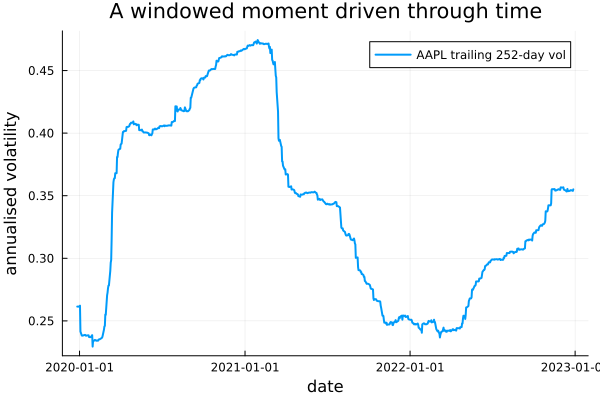

In [7]:
roll = 252
rolling_vol = [sqrt(cov(WindowedCovariance(; window = roll), rd.X[1:t, :])[1, 1]) *
               sqrt(252) for t in roll:T]
rolling_dates = rd.ts[roll:T]

plot(rolling_dates, rolling_vol; label = "AAPL trailing 252-day vol", xlabel = "date",
     ylabel = "annualised volatility", legend = :topright, lw = 2,
     title = "A windowed moment driven through time")

The spike through early 2020 is the COVID crash entering the trailing window; the decay afterward
is that same stretch ageing out 252 days later. This is the picture a windowed estimator gives you
one slice at a time — and the motivation for reaching for one at all.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*